# 05. Evaluarea finală pe rândurile CNAM etichetate manual și explicarea modelelor

**Proiect:** Integrarea probabilistă a registrelor farmaceutice oficiale din Republica Moldova și analiza prețurilor medicamentelor echivalente.
**Autor:** Olesea Popa, grupa SD251M, UTM.

Notebook-ul 04 a comparat modelele de potrivire pe setul semisintetic, construit de noi. Aici le evaluăm pe date reale, adică pe cele 200 de rânduri ale listei CNAM etichetate manual față de Nomenclator. Aceste etichete nu au fost folosite nicăieri până acum, nici la construirea setului semisintetic, nici la antrenarea sau ajustarea modelelor, deci evaluarea este cinstită. Eșantionul este stratificat, cu 100 de rânduri din cele potrivite exact după normalizare și 100 din cele nepotrivite, așa că rezultatele sunt reponderate ca să descrie întreaga listă. Calculăm intervale de încredere, verificăm calibrarea probabilităților, facem o analiză de sensibilitate, citim greșelile modelelor și explicăm deciziile lor prin SHAP și LIME. În final alegem modelul și salvăm lista CNAM legată de Nomenclator.

Criteriul de alegere a fost stabilit înainte de evaluare. Câștigă modelul cu cel mai mare F1 reponderat pe rânduri. Dacă intervalele de încredere ale celor mai buni se suprapun, alegem varianta bayesiană a modelului Fellegi–Sunter unu-la-unu, pentru că nu are nevoie de etichete și dă pentru fiecare rând un interval al probabilității. Codul se află în fișierul src/evaluation.py.

## 0. Pregătirea mediului

**Ce căutăm.** Încărcăm etichetele, informațiile despre straturi și ponderi, jurnalul pre-completărilor, deciziile modelelor salvate de notebook-ul 04 și modelele antrenate. Fișierul Excel al etichetelor este doar citit, nu modificat.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np                 # calcule numerice
import pandas as pd                # tabele de date
import matplotlib.pyplot as plt    # grafice
import seaborn as sns              # grafice statistice, peste matplotlib
import joblib                      # modelele salvate de notebook-ul 04

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")

from labeling import read_labels                                               # etichetele manuale
from evaluation import label_truth, outcomes, weighted_metrics, stratified_bootstrap, SEED
from models import FEATURES, features
from compare import LEVEL_COLS

FIG = ROOT / "reports" / "figures"
INTERIM, LABELS, PROCESSED = ROOT / "data" / "interim", ROOT / "data" / "labels", ROOT / "data" / "processed"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})
pd.set_option("display.max_colwidth", 50, "display.width", 220)

n = pd.read_csv(INTERIM / "nomenclator_link.csv", dtype={"cod": str})                  # index ib = poziția în tabel
nn = n.drop_duplicates("cod").set_index("cod")
ro = pd.read_csv(INTERIM / "cnam_ro_link.csv", dtype=str).set_index("ia")
ro.index = ro.index.astype(int)
pot = pd.read_csv(INTERIM / "potriviri_cnam.csv", dtype=str).set_index("id_cnam")
pot.index = pot.index.astype(int)
pairs = pd.read_csv(INTERIM / "perechi_cnam_probabilitati.csv")
saved = joblib.load(INTERIM / "modele.joblib")

labels = read_labels(LABELS / "etichetare_cnam.xlsx")
info = pd.read_csv(LABELS / "esantion_info.csv").set_index("id_cnam")
journal = pd.read_csv(LABELS / "jurnal_etichetare.csv", dtype=str)
prefilled = set(journal[journal.tip.str.startswith("pre-completare")].id_cnam.astype(int))
truth = label_truth(labels, n)

MODELS = {"regresie logistică": "lr", "SVM (RBF)": "svm", "rețea neuronală": "mlp",
          "Fellegi–Sunter clasic": "fs_clasic", "Fellegi–Sunter unu-la-unu": "fs_unu_la_unu",
          "Fellegi–Sunter bayesian": "fs_bayesian"}
print(f"Rânduri etichetate: {len(truth)}; tipuri: {truth.eticheta.value_counts().to_dict()}")
print(f"Rânduri pre-completate automat și confirmate: {len(prefilled)}")

Rânduri etichetate: 200; tipuri: {'pereche': 146, 'niciunul': 52, 'incert': 2}
Rânduri pre-completate automat și confirmate: 91


**Ce am obținut.** Cele 200 de rânduri etichetate se împart în 146 de rânduri pentru care s-a găsit produsul din Nomenclator, 52 de rânduri marcate NICIUNUL, pentru că produsul nu există în Nomenclator, și 2 rânduri marcate INCERT. Pentru 91 de rânduri eticheta a fost pre-completată automat și apoi confirmată manual.

## 1. Etichetele, straturile și proporția rândurilor cu pereche

**Ce căutăm.** Vedem cum se împart etichetele pe cele două straturi și ce pondere are fiecare rând. Ponderea este mărimea stratului în lista completă împărțită la numărul de rânduri din eșantion, adică 1.972 împărțit la 100 pentru rândurile potrivite exact și 195 împărțit la 100 pentru cele nepotrivite. Cu aceste ponderi estimăm proporția rândurilor CNAM care au pereche în Nomenclator și o comparăm cu estimarea făcută fără etichete de modelul Fellegi–Sunter în notebook-ul 04, între 94,5% și 96,7%.

In [2]:
t = truth.join(info)
print(pd.crosstab(t.strat, t.eticheta, margins=True, margins_name="total").to_string())
print("\nPonderi:", info.groupby("strat").pondere.first().to_dict())
print("Pre-completate pe straturi:", pd.Series(t.index.isin(prefilled), index=t.index).groupby(t.strat).sum().to_dict())

keep = t.index[t.eticheta != "incert"]                     # cele 2 rânduri INCERT sunt tratate separat (secțiunea 4)
w = info.pondere
share = (w[keep] * t.loc[keep, "eticheta"].eq("pereche")).sum() / w[keep].sum()
boot = []
rng = np.random.default_rng(SEED)
for _ in range(2000):                                       # bootstrap stratificat pentru proporție
    idx = np.concatenate([rng.choice(g, len(g)) for _, g in t.loc[keep].groupby("strat").groups.items()])
    boot.append((w[idx] * t.loc[idx, "eticheta"].eq("pereche")).sum() / w[idx].sum())
print(f"\nProporția rândurilor CNAM cu pereche în Nomenclator, din etichete: {share:.3f} "
      f"(IC 95%: {np.percentile(boot, 2.5):.3f}–{np.percentile(boot, 97.5):.3f})")

eticheta        incert  niciunul  pereche  total
strat                                           
nepotrivit           1        51       48    100
potrivit exact       1         1       98    100
total                2        52      146    200

Ponderi: {'nepotrivit': 1.95, 'potrivit exact': 19.72}
Pre-completate pe straturi: {'nepotrivit': 0, 'potrivit exact': 91}



Proporția rândurilor CNAM cu pereche în Nomenclator, din etichete: 0.944 (IC 95%: 0.920–0.960)


**Ce am obținut.** În stratul rândurilor potrivite exact, 98 de rânduri au pereche, unul nu are, iar unul este incert. În stratul rândurilor nepotrivite, 48 au pereche, 51 nu au, iar unul este incert. Cele 91 de etichete pre-completate se află toate în stratul rândurilor potrivite exact. Fiecare rând din acest strat are ponderea 19,72, iar fiecare rând din stratul nepotrivit are ponderea 1,95. Cu aceste ponderi, proporția rândurilor CNAM care au pereche în Nomenclator este estimată la 94,4%, cu un interval de încredere de la 92,0% la 96,0%. Modelul Fellegi–Sunter unu-la-unu estimase aceeași proporție, fără nicio etichetă, la 95,6%, cu intervalul de la 94,5% la 96,7%. Cele două intervale se suprapun.

**Constatare 1.** Aproximativ 94% dintre medicamentele compensate de CNAM au pereche în Nomenclatorul AMDM, cu un interval de încredere de la 92,0% la 96,0%, iar restul nu se regăsesc în Nomenclator. Estimarea obținută fără etichete de modelul Fellegi–Sunter unu-la-unu, 95,6%, este compatibilă cu cea obținută din etichetarea manuală.

## 2. Blocarea pe date reale

**Ce căutăm.** Un produs corect care nu ajunge printre candidați după blocare nu poate fi găsit de niciun model. Pe setul semisintetic blocarea a păstrat 99,97% dintre perechile corecte. Verificăm acum pe datele reale. Pentru fiecare rând etichetat cu un produs, căutăm dacă printre candidații lui se află un cod din clasa de produs corectă.

In [3]:
cand_cls = (pairs[["ia", "ib"]].assign(clasa=n.clasa_produs.reindex(pairs.ib).to_numpy())
            .groupby("ia").clasa.agg(set))
with_pair = t.index[t.eticheta == "pereche"]
found = pd.Series([bool(cand_cls.get(i, set()) & t.loc[i, "clase_corecte"]) for i in with_pair], index=with_pair)
print(f"Rânduri etichetate cu pereche: {len(with_pair)}; perechea corectă se află printre candidați: {found.sum()} ({found.mean():.1%})")
if (~found).any():
    print(ro.loc[found.index[~found], ["denumire", "doza", "forma"]].join(t["cod_corect"]).to_string())

Rânduri etichetate cu pereche: 146; perechea corectă se află printre candidați: 146 (100.0%)


**Ce am obținut.** Pentru toate cele 146 de rânduri etichetate cu pereche, produsul corect se află printre candidații aduși de blocare. Completitudinea blocării este deci de 100% și pe datele reale, iar toate greșelile de mai jos aparțin modelelor, nu blocării.

## 3. Rezultatele modelelor pe etichete

**Ce căutăm.** Pentru fiecare model comparăm decizia cu eticheta. O legătură este corectă dacă produsul ales are clasa de produs a celui etichetat. Un rând etichetat NICIUNUL este tratat corect dacă modelul nu îl leagă. Calculăm, cu ponderile straturilor, precizia, adică ce parte din legăturile făcute sunt corecte, recall-ul, adică ce parte din rândurile care au pereche au fost legate corect, F1 și acuratețea, adică ce parte din rânduri au fost tratate corect, inclusiv cele fără pereche. Intervalele de încredere de 95% sunt obținute prin bootstrap stratificat, cu 2.000 de reeșantionări. Raportăm separat și proporția rândurilor tratate corect în fiecare strat, fără ponderi.

In [4]:
rows, outc = [], {}
for name, key in MODELS.items():
    o = outcomes(pot[f"{key}_cod"], truth, n).loc[keep].join(info.strat)
    outc[name] = o
    m = weighted_metrics(o, w)
    ci = stratified_bootstrap(o, w, info.strat, n_boot=2000, seed=SEED)
    rows.append({"model": name, **{k: m[k] for k in ["precizie", "recall", "F1", "acuratețe"]},
                 "F1 inf": ci.loc["F1", "inf"], "F1 sup": ci.loc["F1", "sup"],
                 "acuratețe inf": ci.loc["acuratețe", "inf"], "acuratețe sup": ci.loc["acuratețe", "sup"],
                 "corecte, strat potrivit exact": o[o.strat == "potrivit exact"].bine.mean(),
                 "corecte, strat nepotrivit": o[o.strat == "nepotrivit"].bine.mean(),
                 "legături greșite": m["legături greșite"], "perechi ratate": m["perechi ratate"]})
rez = pd.DataFrame(rows).set_index("model")
rez.round(3)

,precizie,recall,F1,acuratețe,F1 inf,F1 sup,acuratețe inf,acuratețe sup,"corecte, strat potrivit exact","corecte, strat nepotrivit",legături greșite,perechi ratate
model,,,,,,,,,,,,
regresie logistică,0.989,0.980,0.984,0.980,0.963,0.997,0.959,0.994,0.990,0.879,2,11
SVM (RBF),0.986,0.980,0.983,0.977,0.961,0.995,0.955,0.991,0.990,0.848,5,11
rețea neuronală,0.988,0.980,0.984,0.979,0.962,0.996,0.957,0.992,0.990,0.869,3,11
Fellegi–Sunter clasic,0.927,0.942,0.934,0.930,0.886,0.977,0.882,0.972,0.929,0.939,13,0
Fellegi–Sunter unu-la-unu,0.997,0.989,0.993,0.987,0.982,1.000,0.967,0.999,0.990,0.960,3,2
Fellegi–Sunter bayesian,0.997,0.989,0.993,0.987,0.982,1.000,0.967,0.999,0.990,0.960,3,2


**Ce am obținut.** Modelul Fellegi–Sunter unu-la-unu și varianta lui bayesiană iau aceleași decizii și au cele mai bune rezultate. Precizia lor reponderată este 0,997, recall-ul 0,989, F1 0,993, cu intervalul de la 0,982 la 1,000, iar acuratețea 0,987. Modelele supervizate urmează aproape la egalitate. Regresia logistică și rețeaua neuronală au F1 0,984, iar SVM-ul 0,983, cu intervale care încep de la aproximativ 0,96. Modelul clasic rămâne mult în urmă, cu precizia 0,927 și F1 0,934. În stratul rândurilor potrivite exact, toate modelele în afară de cel clasic tratează corect 99% dintre rânduri. Diferențele apar în stratul dificil, unde modelul unu-la-unu tratează corect 96% dintre rânduri, modelul clasic 94%, regresia logistică 88%, rețeaua neuronală 87% și SVM-ul 85%. Modelele supervizate ratează fiecare câte 11 rânduri care au pereche, față de 2 la modelul unu-la-unu.

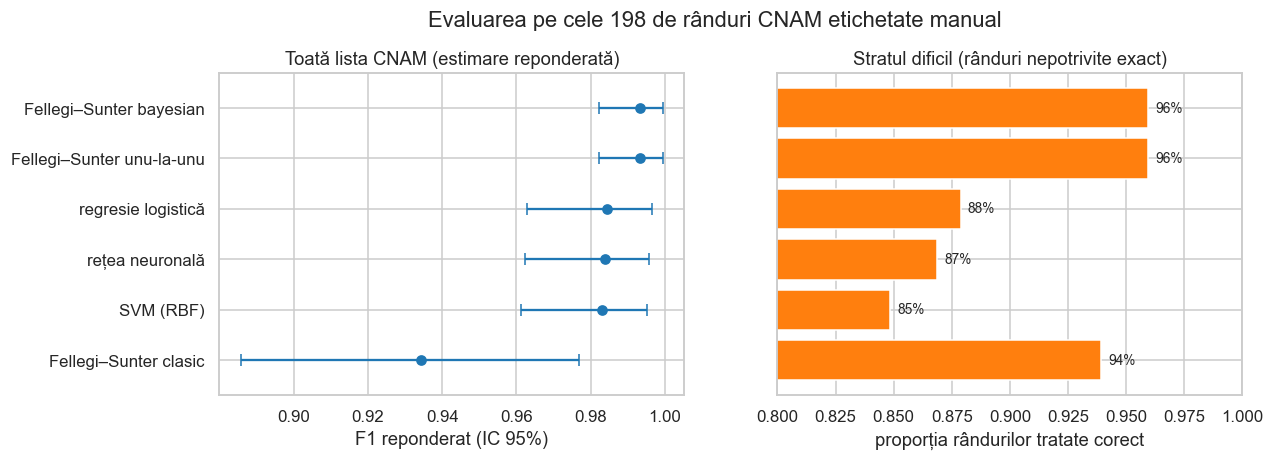

In [5]:
# Figura 14: F1 reponderat cu intervalul de 95% și proporția rândurilor corecte în stratul dificil
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
order = rez.sort_values("F1").index
y = np.arange(len(order))
axes[0].errorbar(rez.loc[order, "F1"], y, xerr=[rez.loc[order, "F1"] - rez.loc[order, "F1 inf"],
                 rez.loc[order, "F1 sup"] - rez.loc[order, "F1"]], fmt="o", color="#1f77b4", capsize=4)
axes[0].set_yticks(y); axes[0].set_yticklabels(order)
axes[0].set_xlabel("F1 reponderat (IC 95%)"); axes[0].set_title("Toată lista CNAM (estimare reponderată)")
axes[1].barh(y, rez.loc[order, "corecte, strat nepotrivit"], color="#ff7f0e")
axes[1].set_xlim(0.8, 1.0); axes[1].set_xlabel("proporția rândurilor tratate corect")
axes[1].set_title("Stratul dificil (rânduri nepotrivite exact)")
for yi, v in zip(y, rez.loc[order, "corecte, strat nepotrivit"]):
    axes[1].text(v + 0.003, yi, f"{v:.0%}", va="center", fontsize=9)
fig.suptitle("Evaluarea pe cele 198 de rânduri CNAM etichetate manual", y=1.03)
fig.savefig(FIG / "fig14_evaluare_etichete.png")
plt.show()

**Ce am obținut.** Figura 14 arată în stânga F1 reponderat cu intervalul de încredere. Intervalele modelului unu-la-unu și ale modelelor supervizate se suprapun parțial, iar intervalul modelului clasic este mult mai jos și mai larg. În dreapta se vede că diferența dintre modele vine aproape în întregime din stratul dificil, unde modelul unu-la-unu tratează corect cu 8 până la 11 puncte procentuale mai multe rânduri decât modelele supervizate.

**Constatare 2.** Pe rândurile CNAM etichetate manual, modelul Fellegi–Sunter cu constrângerea unu-la-unu, estimat fără etichete, are cel mai mare F1 reponderat, 0,993, cu intervalul de la 0,982 la 1,000, urmat la mică distanță de regresia logistică, rețeaua neuronală și SVM, între 0,983 și 0,984. Avantajul lui se concentrează pe rândurile dificile, unde tratează corect 96% dintre rânduri, față de 85% până la 88% la modelele supervizate.

## 4. Analiza de sensibilitate

**Ce căutăm.** Verificăm dacă concluziile depind de două alegeri. Prima alegere privește cele 91 de etichete pre-completate automat și apoi confirmate. Dacă pre-completarea ar fi influențat etichetele, rezultatele s-ar putea schimba fără ele. Pre-completările se află însă aproape toate în stratul ușor, așa că, scoțându-le, rămân mai ales cazuri dificile, iar toate cifrele scad. De aceea urmărim dacă se păstrează ordinea modelelor, nu nivelul cifrelor. A doua alegere privește cele două rânduri INCERT, Brizal și Magnicor, pe care analiza principală le exclude. Le includem pe rând ca NICIUNUL și ca pereche cu produsul ales de model.

In [6]:
sens = {}
for name, o in outc.items():
    no_pref = o.loc[[i for i in o.index if i not in prefilled]]
    unc = outcomes(pot[f"{MODELS[name]}_cod"], truth, n).join(info.strat)
    as_none = unc.copy()                                          # INCERT considerat NICIUNUL
    as_none.loc[as_none.eticheta == "incert", ["are_pereche"]] = False
    as_none["bine"] = np.where(as_none.are_pereche, as_none.corect, ~as_none.legat)
    as_pair = unc.copy()                                          # INCERT considerat corect dacă modelul îl leagă
    inc = as_pair.eticheta == "incert"
    as_pair.loc[inc, "are_pereche"] = True
    as_pair.loc[inc, "corect"] = as_pair.loc[inc, "legat"]
    as_pair["bine"] = np.where(as_pair.are_pereche, as_pair.corect, ~as_pair.legat)
    sens[name] = {"F1 principal": rez.loc[name, "F1"],
                  "F1 fără pre-completate": weighted_metrics(no_pref, w)["F1"],
                  "rânduri fără pre-completate": len(no_pref),
                  "F1, INCERT = NICIUNUL": weighted_metrics(as_none, w)["F1"],
                  "F1, INCERT = pereche": weighted_metrics(as_pair, w)["F1"]}
sens = pd.DataFrame(sens).T
sens["loc principal"] = sens["F1 principal"].rank(ascending=False, method="min").astype(int)
sens["loc fără pre-completate"] = sens["F1 fără pre-completate"].rank(ascending=False, method="min").astype(int)
print("Decizia modelelor pentru cele două rânduri INCERT:")
print(pot.loc[truth.index[truth.eticheta == "incert"], [f"{k}_cod" for k in MODELS.values()]].join(ro.denumire).to_string(), "\n")
sens.round(3)

Decizia modelelor pentru cele două rânduri INCERT:
     lr_cod svm_cod     mlp_cod fs_clasic_cod fs_unu_la_unu_cod fs_bayesian_cod  denumire
id                                                                                       
180     NaN     NaN         NaN    0208390033        0208390033      0208390033    Brizal
1129    NaN     NaN  0109600015    0109600015               NaN             NaN  Magnicor 



,F1 principal,F1 fără pre-completate,rânduri fără pre-completate,"F1, INCERT = NICIUNUL","F1, INCERT = pereche",loc principal,loc fără pre-completate
regresie logistică,0.984,0.870,108.0,0.984,0.979,3,3
SVM (RBF),0.983,0.860,108.0,0.983,0.978,5,5
rețea neuronală,0.984,0.866,108.0,0.983,0.979,4,4
Fellegi–Sunter clasic,0.934,0.498,108.0,0.929,0.935,6,6
Fellegi–Sunter unu-la-unu,0.993,0.943,108.0,0.988,0.993,1,1
Fellegi–Sunter bayesian,0.993,0.943,108.0,0.988,0.993,1,1


**Ce am obținut.** Fără cele 91 de etichete pre-completate rămân 108 rânduri, mai ales din stratul dificil, iar F1 scade la toate modelele. El ajunge la 0,943 pentru modelul unu-la-unu, între 0,860 și 0,870 pentru modelele supervizate și la 0,498 pentru modelul clasic. Ordinea modelelor rămâne exact aceeași, deci concluzia nu depinde de pre-completare. La cele două rânduri INCERT modelele nu sunt de acord între ele. Modelele unu-la-unu leagă Brizal de un produs, iar Magnicor îl lasă fără pereche, în timp ce modelele supervizate nu leagă Brizal. Oricum ar fi tratate cele două rânduri, F1 se schimbă cu cel mult 0,005, iar ordinea rămâne aceeași.

**Constatare 3.** Concluziile evaluării sunt robuste. Ordinea modelelor rămâne aceeași atât fără cele 91 de etichete pre-completate automat, cât și cu oricare dintre tratările posibile ale celor două rânduri incerte.

## 5. Calibrarea probabilităților pe date reale

**Ce căutăm.** O probabilitate bine calibrată înseamnă că, de exemplu, dintre legăturile cu probabilitatea 0,9 aproximativ 90% sunt corecte. Pentru fiecare rând luăm probabilitatea produsului ales de model și verificăm dacă produsul ales este cel corect. La rândurile fără pereche produsul ales este întotdeauna greșit. Calculăm scorul Brier reponderat, adică eroarea pătratică medie dintre probabilitate și rezultat, și numărăm rândurile corecte pe intervale de probabilitate. Avem doar 198 de rânduri, așa că intervalele sunt largi și le tratăm descriptiv.

In [7]:
cal_rows, bins = [], [0, 0.5, 0.9, 0.99, 1.0]
for name, o in outc.items():
    p = pot.loc[o.index, f"{MODELS[name]}_prob"].astype(float)
    y_ = o.corect.astype(float)
    brier = (w[o.index] * (p - y_) ** 2).sum() / w[o.index].sum()
    g = pd.DataFrame({"p": p, "y": y_}).groupby(pd.cut(p, bins, include_lowest=True), observed=False)
    cal_rows.append({"model": name, "Brier reponderat": brier,
                     **{f"{iv}": f"{int(d.y.sum())}/{len(d)}" for iv, d in g}})
pd.DataFrame(cal_rows).set_index("model").round(4)

,Brier reponderat,"(-0.001, 0.5]","(0.5, 0.9]","(0.9, 0.99]","(0.99, 1.0]"
model,,,,,
regresie logistică,0.0143,0/60,13/13,121/123,0/0
SVM (RBF),0.0114,0/57,7/10,127/129,0/0
rețea neuronală,0.0148,0/59,26/27,108/109,0/1
Fellegi–Sunter clasic,0.0699,0/43,2/3,5/7,133/143
Fellegi–Sunter unu-la-unu,0.0083,0/49,7/9,46/46,91/92
Fellegi–Sunter bayesian,0.0084,0/49,9/11,44/44,91/92


**Ce am obținut.** Modelul unu-la-unu are cel mai mic scor Brier reponderat, 0,008, urmat de SVM cu 0,011, de regresia logistică și rețeaua neuronală cu 0,014 și 0,015 și, la distanță, de modelul clasic cu 0,070. Tabelul pe intervale arată două feluri diferite de calibrare imperfectă. Modelele supervizate sunt prudente. Regresia logistică nu dă niciodată o probabilitate peste 0,99, dar legăturile ei cu probabilitatea între 0,5 și 0,9 sunt corecte în 13 din 13 cazuri. Modelul clasic este prea sigur, iar 10 dintre cele 143 de alegeri cu probabilitatea peste 0,99 sunt greșite. Varianta bayesiană a modelului unu-la-unu este cel mai bine calibrată. Alegerile ei cu probabilitatea peste 0,9 sunt corecte în 135 din 136 de cazuri, iar cele dintre 0,5 și 0,9 în 9 din 11 cazuri, deci probabilitatea mai mică semnalează corect o incertitudine mai mare.

## 6. Greșelile modelelor

**Ce căutăm.** Citim rândurile la care greșește modelul Fellegi–Sunter bayesian și pe cele la care greșește cel mai bun model supervizat, regresia logistică, ca să înțelegem cauzele. Pentru fiecare rând arătăm textul din CNAM, produsul ales de model cu probabilitatea lui și produsul din etichetă.

In [8]:
def errors(name):
    o = outc[name]
    bad = o[~o.bine]
    col = MODELS[name]
    def desc(c):
        return f"{nn.loc[c, 'denumire']}, {nn.loc[c, 'doza']}, {nn.loc[c, 'divizare']}" if isinstance(c, str) else "(fără pereche)"
    return pd.DataFrame({"strat": bad.strat, "CNAM": ro.loc[bad.index, ["denumire", "doza", "forma", "divizare"]].astype(str).agg(", ".join, axis=1),
                         "ales de model": [desc(c) for c in pot.loc[bad.index, f"{col}_cod"]],
                         "probabilitate": pot.loc[bad.index, f"{col}_prob"].astype(float).round(3),
                         "eticheta": [desc(c) for c in bad.cod_corect]})
print("Fellegi–Sunter bayesian:")
print(errors("Fellegi–Sunter bayesian").to_string(), "\n")
print("Regresia logistică:")
print(errors("regresie logistică").to_string())

Fellegi–Sunter bayesian:
               strat                                                                              CNAM                         ales de model  probabilitate                                         eticheta
id                                                                                                                                                                                                          
1073      nepotrivit                              Travopic, 40 mcg/ml, picături oftalmice, soluţie, N1               Glautan, 0,04 mg/ml, N1          0.612                                   (fără pereche)
283   potrivit exact                                 Ciprinol®, 400 mg/200 ml, soluție perfuzabilă, N1                        (fără pereche)          0.500                     Ciprinol®, 400 mg/200 ml, N1
1644      nepotrivit  Indapamid LPH® 1,5 mg, 1,5 mg, comprimate filmate cu eliberare prelungită, N10x3  Indapamid LPH® 1,5 mg, 1,5 mg, N10x3          0.998

**Ce am obținut.** Modelul bayesian greșește la 5 rânduri. Travopic este legat de Glautan, o altă marcă cu aceeași substanță, cu o probabilitate de 0,61, iar rândul era deja semnalat ca nesigur în notebook-ul 04. Ciprinol 400 mg/200 ml rămâne nelegat la o probabilitate de exact 0,50, deoarece doi candidați foarte asemănători își împart probabilitatea. Panzynorm nu este legat, cu 0,43, pentru că CNAM scrie doar componenta principală a dozei. Ukrliv 500 mg este legat de singurul Ukrliv din Nomenclator, care are 250 mg. Indapamid LPH este legat cu 0,998, deși eticheta spune că produsul nu există, deci este singura greșeală făcută cu o probabilitate mare. Regresia logistică greșește la 13 rânduri, iar 11 dintre ele sunt perechi ratate. Aproape toate sunt rânduri la care doza este scrisă diferit în cele două surse, de exemplu Panzimed Forte și Panzynorm cu doar componenta principală, Klamoks BID cu 28,5 mg față de 28 mg, Nimid cu 100 mg față de 100 mg/2 g și Asist Plus cu 600 mg/3 g față de 600 mg. Celelalte, Cefamed și Timonil, au denumirea sau forma scrisă diferit.

**Ce căutăm.** Greșelile modelelor supervizate apar mai ales când doza este scrisă diferit în cele două surse. Verificăm această impresie pe toate rândurile etichetate cu pereche. Comparăm proporția rândurilor legate corect atunci când doza normalizată a perechii corecte este egală și atunci când diferă.

In [9]:
# doza perechii corecte: egală sau diferită față de rândul CNAM (după normalizare)
dose_eq = pd.Series({i: ro.loc[i, "doza_norm"] == nn.loc[t.loc[i, "cod_corect"], "doza_norm"] for i in with_pair})
tab = {}
for name, o in outc.items():
    op = o.loc[with_pair]
    tab[name] = {"doza egală: legate corect": f"{op.corect[dose_eq].sum()}/{dose_eq.sum()}",
                 "doza diferită: legate corect": f"{op.corect[~dose_eq].sum()}/{(~dose_eq).sum()}"}
print("Doze diferite în perechile corecte:")
print(ro.loc[dose_eq.index[~dose_eq], ["denumire", "doza"]].assign(
      doza_Nomenclator=[nn.loc[t.loc[i, "cod_corect"], "doza"] for i in dose_eq.index[~dose_eq]]).to_string(), "\n")
pd.DataFrame(tab).T

Doze diferite în perechile corecte:
                             denumire                   doza             doza_Nomenclator
757                            Nimid®                 100 mg                   100 mg/2 g
1266                     Klamoks® BID  200 mg + 28,5 mg/5 ml            200 mg/28 mg/5 ml
1891                   Panzimed Forte               10000 UI  10000 UI / 7500 UI / 375 UI
1886                 Panzynorm®10 000               10000 UA      10000 UA/7200 UA/400 UA
1895                   Panzimed Forte               10000 UI  10000 UI / 7500 UI / 375 UI
1475  Vitamina D3 Biofarm 18000 UI/ml            18000 UI/ml                   0,45 mg/ml
1875                           Nimid®                 100 mg                   100 mg/2 g
1118                      Asist® Plus             600 mg/3 g                       600 mg 



,doza egală: legate corect,doza diferită: legate corect
regresie logistică,134/138,0/8
SVM (RBF),134/138,0/8
rețea neuronală,134/138,0/8
Fellegi–Sunter clasic,132/138,8/8
Fellegi–Sunter unu-la-unu,137/138,7/8
Fellegi–Sunter bayesian,137/138,7/8


**Ce am obținut.** Doza normalizată diferă la 8 dintre cele 146 de perechi etichetate. Modelele supervizate nu leagă niciuna dintre ele, în timp ce modelul unu-la-unu leagă corect 7 din 8, iar cel clasic toate 8. Când doza este egală, modelul unu-la-unu leagă corect 137 din 138 de perechi, iar modelele supervizate 134 din 138. Explicația ține de datele de antrenare. Modelele supervizate au învățat pe setul semisintetic, unde doza diferă foarte rar, așa că pentru ele o doză diferită înseamnă aproape sigur alt produs. Modelul Fellegi–Sunter își estimează parametrii direct din lista CNAM și învață cât de des diferă doza în datele reale.

**Constatare 4.** Principala sursă de erori a modelelor supervizate este diferența dintre datele de antrenare și datele reale. În setul semisintetic doza diferă rar, așa că modelele supervizate resping toate cele 8 perechi corecte cu doza scrisă diferit, de exemplu doar cu componenta principală a unei combinații. Modelul Fellegi–Sunter, estimat direct pe lista CNAM, leagă corect 7 dintre ele, deoarece se adaptează la felul în care sursa reală scrie datele.

## 7. Explicarea deciziilor: Fellegi–Sunter, SHAP și LIME

**Ce căutăm.** La modelul Fellegi–Sunter explicația este exactă și vine din model. Scorul unei perechi este suma ponderilor log2(m/u) ale nivelurilor ei de acord, deci fiecare câmp are o contribuție proprie. Pentru modelele supervizate folosim SHAP, o metodă bazată pe valorile Shapley din teoria jocurilor. SHAP împarte probabilitatea prezisă între caracteristici, astfel încât contribuțiile să se adune exact la diferența dintre predicție și predicția medie. Calculăm contribuțiile pentru perechea aleasă de fiecare model la cele 198 de rânduri etichetate. Caracteristicile aceluiași câmp, de exemplu cele două scoruri ale denumirii, sunt adunate. Comparăm apoi importanța medie a câmpurilor, exprimată în procente din total, deoarece Fellegi–Sunter lucrează pe scara log a șanselor, iar SHAP pe scara probabilității.

In [10]:
import shap
FIELD_OF = {"sim_denumire": "denumire", "sim_denumire_tok": "denumire", "lipsa_denumire": "denumire",
            "eq_doza": "doza", "sim_doza": "doza", "lipsa_doza": "doza", "eq_forma": "forma", "sim_forma": "forma",
            "eq_unitati": "unitati", "lipsa_unitati": "unitati", "eq_volum": "volum", "lipsa_volum": "volum",
            "sim_firma": "firma", "lipsa_firma": "firma", "eq_dci": "dci", "lipsa_dci": "dci"}
lab_pairs = pairs[pairs.ia.isin(keep)]

def chosen_pairs(prob_col):
    # perechea cu probabilitatea cea mai mare pentru fiecare rând etichetat
    return lab_pairs.loc[lab_pairs.groupby("ia")[prob_col].idxmax()].set_index("ia")

background = features(pairs.sample(200, random_state=SEED))           # fundalul pentru SHAP: perechi CNAM oarecare
shap_imp, shap_vals = {}, {}
for name in ["regresie logistică", "rețea neuronală"]:
    mdl = saved["supervizate"][name]
    X = features(chosen_pairs(f"prob_{name}"))
    f = lambda A, mdl=mdl: mdl.predict_proba(pd.DataFrame(A, columns=FEATURES))[:, 1]
    ex = shap.PermutationExplainer(f, shap.maskers.Independent(background.to_numpy(), max_samples=200), seed=SEED)
    sv = pd.DataFrame(ex(X.to_numpy(), silent=True).values, columns=FEATURES, index=X.index)
    shap_vals[name] = (sv, X)
    shap_imp[name] = sv.T.groupby(FIELD_OF).sum().T.abs().mean()

# Fellegi–Sunter: contribuția exactă a fiecărui câmp = log2(m/u) la nivelul observat (0 dacă lipsește)
fs = saved["fs_cnam"]
fs_ch = chosen_pairs("prob_Fellegi–Sunter bayesian")
contrib = pd.DataFrame({c.replace("niv_", ""): [np.log2(fs["m"][c][int(l)] / fs["u"][c][int(l)]) if pd.notna(l) else 0.0
                                                 for l in fs_ch[c]] for c in LEVEL_COLS}, index=fs_ch.index)
shap_imp["Fellegi–Sunter (log2 m/u)"] = contrib.abs().mean()
imp = pd.DataFrame(shap_imp)
imp_pct = (imp / imp.sum() * 100).round(1)
imp_pct

,regresie logistică,rețea neuronală,Fellegi–Sunter (log2 m/u)
dci,0.6,1.9,1.4
denumire,40.6,36.2,30.3
doza,20.7,19.6,13.7
firma,9.6,13.3,27.2
forma,3.4,1.2,9.5
unitati,19.7,22.2,15.3
volum,5.4,5.6,2.5


**Ce am obținut.** Pentru toate cele trei modele, denumirea este câmpul cel mai important, cu 40,6% din importanța totală la regresia logistică, 36,2% la rețeaua neuronală și 30,3% la Fellegi–Sunter. Urmează numărul de unități și doza, fiecare cu 14% până la 22%. Diferența cea mai mare apare la firmă, care are 27,2% din importanță în modelul Fellegi–Sunter, dar doar 13,3% în rețeaua neuronală și 9,6% în regresia logistică. Modelul Fellegi–Sunter a învățat din lista CNAM că firma este de obicei aceeași la produsul corect și diferită la ceilalți candidați. Modelele supervizate au văzut în setul semisintetic multe mărci cu deținătorul schimbat intenționat, așa că se bazează mai puțin pe firmă. Forma, volumul și substanța activă contează puțin, de la 1% la 10%, pentru că după blocare aproape toți candidații au aceeași substanță, iar volumul există doar la lichide.

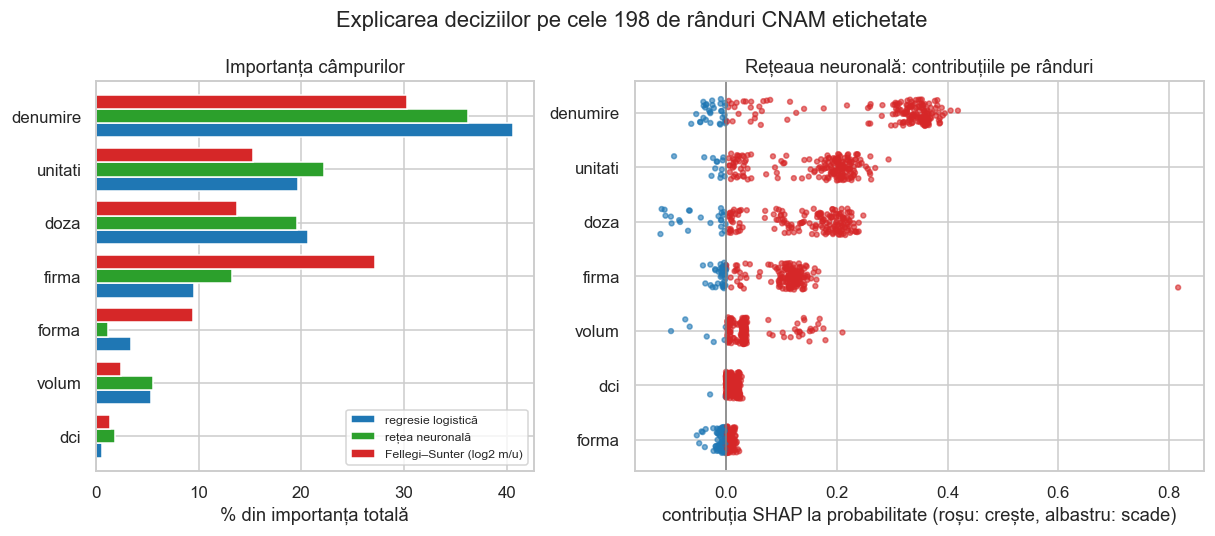

In [11]:
# Figura 15: importanța câmpurilor (procente din total) și contribuțiile SHAP ale rețelei neuronale
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [1, 1.3]})
imp_pct.loc[imp_pct.mean(axis=1).sort_values().index].plot.barh(ax=axes[0], width=0.8,
                                                                color=["#1f77b4", "#2ca02c", "#d62728"])
axes[0].set_xlabel("% din importanța totală"); axes[0].set_title("Importanța câmpurilor")
axes[0].legend(fontsize=8, loc="lower right")
sv, X = shap_vals["rețea neuronală"]
sv_f = sv.T.groupby(FIELD_OF).sum().T
order = sv_f.abs().mean().sort_values().index
for i, c in enumerate(order):
    axes[1].scatter(sv_f[c], np.full(len(sv_f), i) + np.random.default_rng(SEED).uniform(-0.25, 0.25, len(sv_f)),
                    s=10, alpha=0.6, c=np.where(sv_f[c] >= 0, "#d62728", "#1f77b4"))
axes[1].axvline(0, color="grey", lw=1)
axes[1].set_yticks(range(len(order))); axes[1].set_yticklabels(order)
axes[1].set_xlabel("contribuția SHAP la probabilitate (roșu: crește, albastru: scade)")
axes[1].set_title("Rețeaua neuronală: contribuțiile pe rânduri")
fig.suptitle("Explicarea deciziilor pe cele 198 de rânduri CNAM etichetate", y=1.02)
fig.savefig(FIG / "fig15_explicabilitate_shap.png")
plt.show()

**Ce am obținut.** În figura 15, în stânga, se vede importanța câmpurilor pentru cele trei modele. În dreapta, fiecare punct este contribuția unui câmp la probabilitatea dată de rețeaua neuronală pentru un rând. Denumirea identică crește probabilitatea cu 0,3 până la 0,4, numărul de unități și doza egale cu aproximativ 0,2, iar firma cu aproximativ 0,1. Contribuțiile negative vin mai ales din doză și denumire, la candidații respinși. Un singur punct iese în evidență, cu o contribuție a firmei de 0,8. Este rândul 1.267 din lista CNAM, care are doar substanța activă, fără denumire, doză, formă sau firmă. Rețeaua neuronală l-a legat de Augmentin cu probabilitatea 1,0, deci este foarte sigură tocmai acolo unde nu are informații. Modelul Fellegi–Sunter, la care un câmp lipsă nu aduce nicio dovadă, îi dă probabilitatea 0,02, iar eticheta este NICIUNUL.

**Ce căutăm.** LIME explică o singură decizie. El generează multe variante ușor modificate ale perechii, vede cum se schimbă probabilitatea modelului și potrivește pe ele un model liniar simplu, ale cărui ponderi arată ce caracteristici au contat. Îl folosim ilustrativ, pe rețeaua neuronală, pentru patru rânduri alese după reguli fixe. Primul este o legătură corectă cu denumirea scrisă diferit. Al doilea este un rând corect lăsat fără pereche. Al treilea este o pereche ratată din cauza dozei. Al patrulea este un rând pe care varianta bayesiană îl consideră nesigur. Pentru aceleași rânduri arătăm și contribuțiile exacte ale câmpurilor în modelul Fellegi–Sunter.

In [12]:
from lime.lime_tabular import LimeTabularExplainer
o_mlp, o_fs = outc["rețea neuronală"], outc["Fellegi–Sunter bayesian"]
ch_mlp = chosen_pairs("prob_rețea neuronală")
examples = {
    "legătură corectă, denumire diferită": next(i for i in o_mlp.index if o_mlp.loc[i, "corect"] and ch_mlp.loc[i, "sim_denumire"] < 1),
    "corect lăsat fără pereche": next(i for i in o_mlp.index if o_mlp.loc[i, "eticheta"] == "niciunul" and not o_mlp.loc[i, "legat"]),
    "pereche ratată, doză diferită": next(i for i in o_mlp.index if o_mlp.loc[i, "are_pereche"] and not o_mlp.loc[i, "legat"]
                                         and not dose_eq.get(i, True)),
    "nesigur (varianta bayesiană)": next(i for i in o_fs.index if float(pot.loc[i, "fs_bayesian_inf95"]) < 0.5 <= float(pot.loc[i, "fs_bayesian_sup95"])),
}
mdl = saved["supervizate"]["rețea neuronală"]
# LIME variază doar scorurile câmpurilor prezente în perechea explicată; indicatorii de lipsă și scorurile câmpurilor
# lipsă rămân cele ale perechii. Altfel LIME ar genera combinații imposibile, de exemplu un volum „egal” la comprimate,
# unde volumul nu există. Egalitățile 0/1 sunt declarate categoriale, ca să fie variate după frecvența lor reală.
from compare import SIM_COLS
from models import MISSING_FLAGS
lime_bg = features(pairs.sample(3000, random_state=SEED))
lime_rows = []
for label, i in examples.items():
    x = features(ch_mlp.loc[[i]]).iloc[0]
    missing = {col for flag, col in MISSING_FLAGS.items() if x[flag] == 1}
    vary = [c for c in SIM_COLS if c not in missing]
    fixed = [c for c in FEATURES if c not in vary]
    ex_i = LimeTabularExplainer(lime_bg[vary].to_numpy(), feature_names=vary, class_names=["diferit", "același produs"],
                                categorical_features=[j for j, c in enumerate(vary) if c.startswith("eq_")],
                                discretize_continuous=True, random_state=SEED)
    f2 = lambda A, x=x, vary=vary, fixed=fixed: mdl.predict_proba(
        pd.DataFrame(np.column_stack([A, np.tile(x[fixed].to_numpy(), (len(A), 1))]), columns=vary + fixed)[FEATURES])
    e = ex_i.explain_instance(x[vary].to_numpy(), f2, num_features=4, num_samples=3000)
    fs_c = contrib.loc[i]
    lime_rows.append({"exemplu": label, "CNAM": f"{ro.loc[i, 'denumire']}, {ro.loc[i, 'doza']}",
                      "candidat": f"{n.loc[ch_mlp.loc[i, 'ib'], 'denumire']}, {n.loc[ch_mlp.loc[i, 'ib'], 'doza']}",
                      "eticheta": t.loc[i, "eticheta"],
                      "prob. rețea": round(f2(x[vary].to_numpy()[None, :])[0, 1], 3),
                      "LIME (rețea): principalele ponderi": "; ".join(f"{a} ({b:+.2f})" for a, b in e.as_list()),
                      "Fellegi–Sunter: contribuții log2(m/u)": "; ".join(f"{k} {v:+.1f}" for k, v in fs_c[fs_c.abs() > 0.5].round(1).items())})
pd.set_option("display.max_colwidth", 120)
pd.DataFrame(lime_rows).set_index("exemplu").T

exemplu,"legătură corectă, denumire diferită",corect lăsat fără pereche,"pereche ratată, doză diferită",nesigur (varianta bayesiană)
CNAM,"Lerkamen®, 10 mg","Ulcoreks, 40 mg","Nimid®, 100 mg","Travopic, 40 mcg/ml"
candidat,"Lerkamen® 10, 10 mg","Pulcet®, 40 mg","Nimid®, 100 mg/2 g","Travapress, 0,04 mg/ml"
eticheta,pereche,niciunul,pereche,niciunul
prob. rețea,0.954,0.043,0.06,0.039
LIME (rețea): principalele ponderi,sim_denumire_tok > 0.62 (+0.02); eq_unitati=1 (+0.02); eq_doza=1 (+0.01); sim_denumire > 0.83 (+0.01),eq_unitati=1 (+0.01); eq_doza=1 (+0.01); 0.00 < sim_doza <= 1.00 (+0.01); 0.43 < sim_denumire_tok <= 0.62 (-0.00),sim_denumire_tok > 0.62 (+0.02); eq_unitati=1 (+0.01); eq_doza=0 (-0.01); sim_denumire > 0.83 (+0.01),eq_volum=1 (+0.00); eq_unitati=1 (+0.00); eq_doza=1 (+0.00); 0.00 < sim_doza <= 1.00 (+0.00)
Fellegi–Sunter: contribuții log2(m/u),denumire -2.8; doza +1.6; forma +0.9; unitati +1.8; firma +3.3,denumire -7.8; doza +1.6; forma +0.9; unitati +1.8; firma +0.8,denumire +3.4; doza -2.7; forma +0.9; unitati +1.8; firma +3.3,denumire -7.8; doza +1.6; forma +0.9; unitati +1.8; volum +1.6; firma +0.8


**Ce am obținut.** Pentru Lerkamen, legat corect de Lerkamen 10, rețeaua neuronală dă probabilitatea 0,954. LIME arată ca factori pozitivi asemănarea cuvintelor din denumire, numărul de unități egal și doza egală. În modelul Fellegi–Sunter, denumirea doar asemănătoare scade scorul cu 2,8, dar firma, cu plus 3,3, unitățile și doza îl compensează. Pentru Ulcoreks, corect lăsat fără pereche, ambele modele resping candidatul Pulcet, iar în Fellegi–Sunter denumirea diferită scade scorul cu 7,8. La Nimid, rețeaua neuronală respinge perechea corectă, cu probabilitatea 0,06, din cauza dozei scrise diferit. Fellegi–Sunter penalizează și el doza, cu minus 2,7, dar denumirea identică și firma aceeași, fiecare cu plus 3,3 sau 3,4, sunt mai puternice, așa că leagă corect. Pentru Travopic ambele modele resping candidatul. Ponderile LIME sunt foarte mici, sub 0,03, deoarece rețeaua este puternic neliniară. Aproape toate variantele generate de LIME primesc o probabilitate apropiată de 0, iar modelul liniar local explică puțin. LIME rămâne deci doar ilustrativ, în timp ce contribuțiile exacte ale modelului Fellegi–Sunter și valorile SHAP sunt mai ușor de interpretat.

**Constatare 5.** Toate modelele se bazează în primul rând pe denumire, apoi pe numărul de unități și pe doză. Modelul Fellegi–Sunter acordă firmei o importanță mult mai mare decât modelele supervizate, 27% față de 10% până la 13%, și tratează corect câmpurile lipsă. Rețeaua neuronală poate da probabilitatea 1,0 unui rând fără nicio informație. Modelul Fellegi–Sunter oferă o explicație exactă și aditivă a fiecărei decizii, în timp ce explicațiile LIME sunt slabe pentru un model atât de neliniar.

## 8. Modelul ales și lista CNAM legată de Nomenclator

**Ce căutăm.** Aplicăm criteriul stabilit la început și salvăm lista finală. Pentru fiecare rând CNAM păstrăm codul Nomenclatorului ales de modelul câștigător, denumirea, doza, forma și divizarea produsului ales, probabilitatea și intervalul ei credibil. Marcăm pentru verificare manuală rândurile legate cu o probabilitate sub 0,9 și rândurile nelegate al căror interval credibil trece de pragul de 0,5. Pe etichete, legăturile cu probabilitatea de cel puțin 0,9 au fost aproape toate corecte. În final numărăm câte dintre rândurile legate au un preț în Catalogul de prețuri, pentru analiza prețurilor din notebook-ul următor.

In [13]:
# Varianta EM și cea bayesiană a modelului unu-la-unu iau aceleași decizii, deci comparăm varianta bayesiană
# cu cel mai bun model din celelalte familii
fs_b = rez.loc["Fellegi–Sunter bayesian"]
others = rez.drop(["Fellegi–Sunter bayesian", "Fellegi–Sunter unu-la-unu"])
rival = others.F1.idxmax()
overlap = (fs_b["F1 inf"] <= others.loc[rival, "F1 sup"]) and (others.loc[rival, "F1 inf"] <= fs_b["F1 sup"])
winner = "Fellegi–Sunter bayesian" if (fs_b.F1 >= others.loc[rival, "F1"] or overlap) else rival
print(f"Fellegi–Sunter bayesian: F1 {fs_b.F1:.3f} ({fs_b['F1 inf']:.3f}–{fs_b['F1 sup']:.3f}); "
      f"cel mai bun rival: {rival}, F1 {others.loc[rival, 'F1']:.3f} ({others.loc[rival, 'F1 inf']:.3f}–{others.loc[rival, 'F1 sup']:.3f})")
print(f"Intervalele se suprapun: {overlap}. Modelul ales: {winner}")

k = MODELS[winner]
final = ro[["dci", "denumire", "doza", "forma", "divizare", "volum", "producator", "grup", "statut_compensare"]].copy()
final.index.name = "id_cnam"
final["cod_nomenclator"] = pot[f"{k}_cod"].reindex(final.index)
final["probabilitate"] = pot[f"{k}_prob"].astype(float).reindex(final.index)
final["inf95"] = pot["fs_bayesian_inf95"].astype(float).reindex(final.index)
final["sup95"] = pot["fs_bayesian_sup95"].astype(float).reindex(final.index)
for col in ["denumire", "doza", "forma", "divizare", "detinator"]:
    final[f"{col}_nomenclator"] = final.cod_nomenclator.map(nn[col])
linked = final.cod_nomenclator.notna()
final["de_verificat"] = (linked & (final.probabilitate < 0.9)) | (~linked & (final.sup95 >= 0.5))

cat = pd.read_csv(INTERIM / "catalog_clean.csv", dtype={"cod": str})
final["are_pret_catalog"] = final.cod_nomenclator.isin(set(cat.cod))
PROCESSED.mkdir(exist_ok=True)
final.to_csv(PROCESSED / "cnam_legat_nomenclator.csv")
print(f"\nRânduri CNAM: {len(final)}; legate: {linked.sum()} ({linked.mean():.1%}); "
      f"de verificat manual: {final.de_verificat.sum()}")
print(f"Rânduri legate care au preț în Catalog: {final.are_pret_catalog.sum()} ({final.are_pret_catalog[linked].mean():.1%} din cele legate)")
print(f"Coduri distincte din Nomenclator în lista legată: {final.cod_nomenclator.nunique()}")

Fellegi–Sunter bayesian: F1 0.993 (0.982–1.000); cel mai bun rival: regresie logistică, F1 0.984 (0.963–0.997)
Intervalele se suprapun: True. Modelul ales: Fellegi–Sunter bayesian

Rânduri CNAM: 2167; legate: 2073 (95.7%); de verificat manual: 99
Rânduri legate care au preț în Catalog: 1909 (92.1% din cele legate)
Coduri distincte din Nomenclator în lista legată: 1089


**Ce am obținut.** Varianta bayesiană a modelului Fellegi–Sunter unu-la-unu are F1 0,993, cu intervalul de la 0,982 la 1,000, iar cel mai bun rival, regresia logistică, are 0,984, cu intervalul de la 0,963 la 0,997. Varianta bayesiană are F1 mai mare, iar intervalele se suprapun, așa că ea este modelul ales după oricare dintre cele două reguli stabilite la început. Lista finală leagă 2.073 dintre cele 2.167 de rânduri CNAM, adică 95,7%, de 1.089 de coduri distincte din Nomenclator. 99 de rânduri sunt marcate pentru verificare manuală. 1.909 dintre rândurile legate, adică 92,1%, au un preț în Catalogul național de prețuri, deci pot intra în analiza prețurilor.

**Constatare 6.** Modelul ales pentru integrarea registrelor este varianta bayesiană a modelului Fellegi–Sunter cu constrângerea unu-la-unu. Ea are cel mai bun F1 pe datele reale, nu are nevoie de etichete, deci poate fi aplicată din nou pe versiuni noi ale listelor, și dă pentru fiecare rând un interval de incertitudine. Cu ea, 95,7% dintre rândurile listei CNAM sunt legate de Nomenclator, iar 92,1% dintre rândurile legate au preț în Catalogul de prețuri.

## 9. Rezumat

Pe cele 198 de rânduri CNAM etichetate manual și neutilizate până acum, modelul Fellegi–Sunter cu constrângerea unu-la-unu, estimat fără etichete, a obținut cel mai mare F1 reponderat, 0,993. Modelele supervizate au rezultate apropiate pe rândurile ușoare, dar pierd perechile la care doza este scrisă diferit, pentru că au învățat pe un set semisintetic în care asemenea diferențe sunt rare. Concluzia rămâne aceeași fără etichetele pre-completate și oricum ar fi tratate cele două rânduri incerte. Proporția medicamentelor compensate care au pereche în Nomenclator, estimată fără etichete, se confirmă pe etichete, la aproximativ 94%. Explicațiile arată că toate modelele se bazează în primul rând pe denumire, unități și doză, iar modelul Fellegi–Sunter și pe firmă. Ele mai arată că rețeaua neuronală poate fi foarte sigură și pe un rând fără nicio informație.

Lista CNAM legată de Nomenclator este salvată în data/processed/cnam_legat_nomenclator.csv, cu codul, probabilitatea, intervalul credibil și indicatorul de verificare manuală. În pasul următor ea va fi legată, prin cod, de prețurile din Catalog, pentru analiza dispersiei prețurilor între medicamentele echivalente compensate.